<a href="https://colab.research.google.com/github/Chandrika-Saha/Machine-Learning-Algos/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!mkdir -p /content/drive/MyDrive/.kaggle

Mounted at /content/drive


In [2]:
# from google.colab import files
# files.upload()

In [3]:
!mv kaggle.json /content/drive/MyDrive/.kaggle/kaggle.json
!ls -la /content/drive/MyDrive/.kaggle

mv: cannot stat 'kaggle.json': No such file or directory
total 1
-rw------- 1 root root 68 Feb 22 18:49 kaggle.json


In [4]:
!mkdir -p /root/.config/kaggle
!cp /content/drive/MyDrive/.kaggle/kaggle.json /root/.config/kaggle/

In [5]:
!kaggle -v

Kaggle API 1.7.4.5


In [6]:
!kaggle datasets list -s titanic

ref                                  title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------  ---------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
heptapod/titanic                     Titanic                                             11090  2017-05-16 08:14:22.210000         147164       1893  0.7058824        
brendan45774/test-file               Titanic dataset                                     11514  2021-12-02 16:11:42.367000         223936       1741  1.0              
yasserh/titanic-dataset              Titanic Dataset                                     22564  2021-12-24 14:53:06.913000         284040        871  1.0              
azeembootwala/titanic                Titanic                                             12406  2017-06-05 12:14:37.477000          26566        210  0.8235294 

In [7]:
!kaggle datasets files heptapod/titanic

name                  size  creationDate                
-------------------  -----  --------------------------  
train_and_test2.csv  83879  2019-09-20 15:44:27.234000  


In [8]:
!kaggle datasets download heptapod/titanic

Dataset URL: https://www.kaggle.com/datasets/heptapod/titanic
License(s): DbCL-1.0
  0% 0.00/10.8k [00:00<?, ?B/s]
100% 10.8k/10.8k [00:00<00:00, 35.4MB/s]


In [9]:
import os
if not os.path.exists("/content/drive/MyDrive/titanic"):

  !kaggle datasets download -d -p /content/drive/MyDrive/
  !unzip /content/drive/MyDrive/titanic.zip -d /content/drive//MyDrive/titanic


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
filepath = "/content/drive/MyDrive/titanic/train_and_test2.csv"
df = pd.read_csv(filepath)
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [12]:
df.shape

(1309, 28)

In [13]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

None

In [14]:
df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', '2urvived'],
      dtype='object')

In [15]:
df.rename(columns={'2urvived': 'survived'}, inplace=True)
df.columns = (df.columns.str.strip().str.lower().str.replace(' ', ''))
print(df.columns)

Index(['passengerid', 'age', 'fare', 'sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'pclass', 'zero.15', 'zero.16', 'embarked', 'zero.17',
       'zero.18', 'survived'],
      dtype='object')


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
passengerid,1309.0,655.000000,378.020061,1.00,328.0000,655.0000,982.000,1309.0000
age,1309.0,29.503186,12.905241,0.17,22.0000,28.0000,35.000,80.0000
fare,1309.0,33.281086,51.741500,0.00,7.8958,14.4542,31.275,512.3292
sex,1309.0,0.355997,0.478997,0.00,0.0000,0.0000,1.000,1.0000
sibsp,1309.0,0.498854,1.041658,0.00,0.0000,0.0000,1.000,8.0000
zero,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000
zero.1,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000
zero.2,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000
zero.3,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000
zero.4,1309.0,0.000000,0.000000,0.00,0.0000,0.0000,0.000,0.0000


# Sanity Check

In [17]:
print(f"\nData types:\n{df.dtypes}")
print(f"\nDupicate rows: {df.duplicated().sum()}")

missing = df.isna().sum().sort_values(ascending=False)
print(f"Missing values:\n{missing}")

uniques = df.nunique().sort_values(ascending=False)
print(f"\nCardinality:\n{uniques}")


Data types:
passengerid      int64
age            float64
fare           float64
sex              int64
sibsp            int64
zero             int64
zero.1           int64
zero.2           int64
zero.3           int64
zero.4           int64
zero.5           int64
zero.6           int64
parch            int64
zero.7           int64
zero.8           int64
zero.9           int64
zero.10          int64
zero.11          int64
zero.12          int64
zero.13          int64
zero.14          int64
pclass           int64
zero.15          int64
zero.16          int64
embarked       float64
zero.17          int64
zero.18          int64
survived         int64
dtype: object

Dupicate rows: 0
Missing values:
embarked       2
passengerid    0
fare           0
age            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
sex            0
zero.6         0
parch          0
zero.8         0
zero.7         0
zero.10        0
zero.1

# Identify column groups

In [18]:
zero_cols = [col for col in df.columns if "zero" in col]
print(f"The zero columns are: {zero_cols}")
df.drop(columns=zero_cols, inplace=True)

TARGET = "survived"

num_cols = df.select_dtypes(include=[np.number]).columns.to_list()
cat_cols = df.select_dtypes(include=["object", "bool"]).columns.to_list()

if TARGET in num_cols:
  num_cols.remove(TARGET)
if TARGET in cat_cols:
  cat_cols.remove(TARGET)

num_cols = [col for col in num_cols if col not in ['pclass',
       'embarked']]
cat_cols.extend(['pclass', 'embarked'])

print(f"The target column is: {TARGET}")
print(f"The numerical columns are: {num_cols}")
print(f"The categorical columns are: {cat_cols}")

The zero columns are: ['zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'zero.15', 'zero.16', 'zero.17', 'zero.18']
The target column is: survived
The numerical columns are: ['passengerid', 'age', 'fare', 'sex', 'sibsp', 'parch']
The categorical columns are: ['pclass', 'embarked']


# Univariate analysis

In [19]:
def plot_hist(series, title, bins=50, log=False):
  series = series.dropna()
  plt.figure(figsize=(10, 5))
  series = np.log1p(series) if log else series
  title = title + " (log)" if log else title
  plt.title(title)
  sns.histplot(series, kde=True)
  plt.xlabel(series.name)
  plt.ylabel("count")
  plt.show()

In [20]:
def plot_box(series, title):
  series = series.dropna()
  plt.figure(figsize=(10, 5))
  plt.title(title)
  plt.boxplot(series)
  plt.xlabel(series.name)
  plt.show()

In [21]:
num_cols

['passengerid', 'age', 'fare', 'sex', 'sibsp', 'parch']

Target summary: count    1309.000000
mean        0.261268
std         0.439494
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: survived, dtype: float64
Target skew: 1.0880574700955759
Target kurtosis: -0.8173821444476141


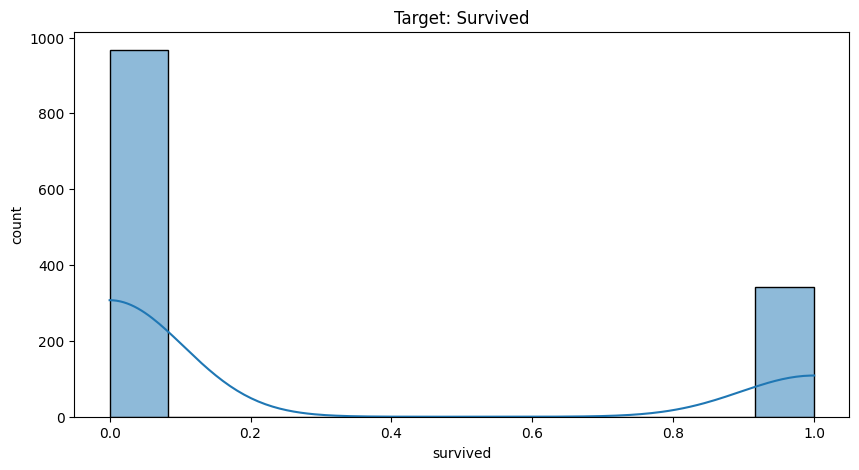

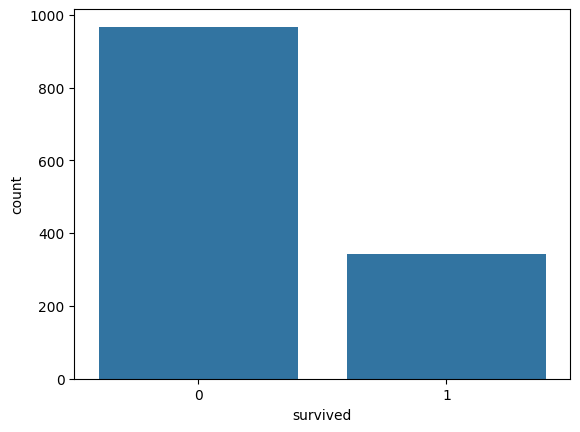

In [22]:
print(f"Target summary: {df[TARGET].describe()}")
print(f"Target skew: {df[TARGET].skew()}")
print(f"Target kurtosis: {df[TARGET].kurtosis()}")

plot_hist(df[TARGET], "Target: Survived", bins=50, log=False)
sns.countplot(x=TARGET, data=df)
plt.show()


passengerid summary: count    1309.000000
mean      655.000000
std       378.020061
min         1.000000
25%       328.000000
50%       655.000000
75%       982.000000
max      1309.000000
Name: passengerid, dtype: float64
passengerid skew: 0.0
passengerid negative: 0, zero: 0, positive: 1309
passengerid log1p skewness: -1.7820961712761905


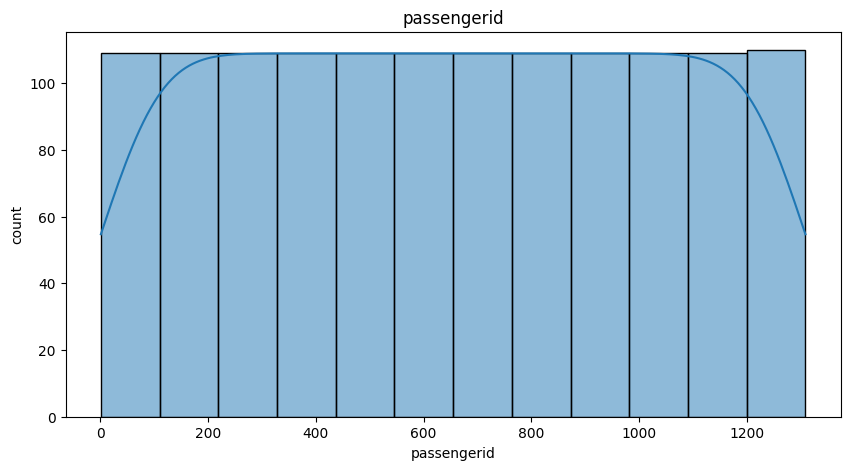

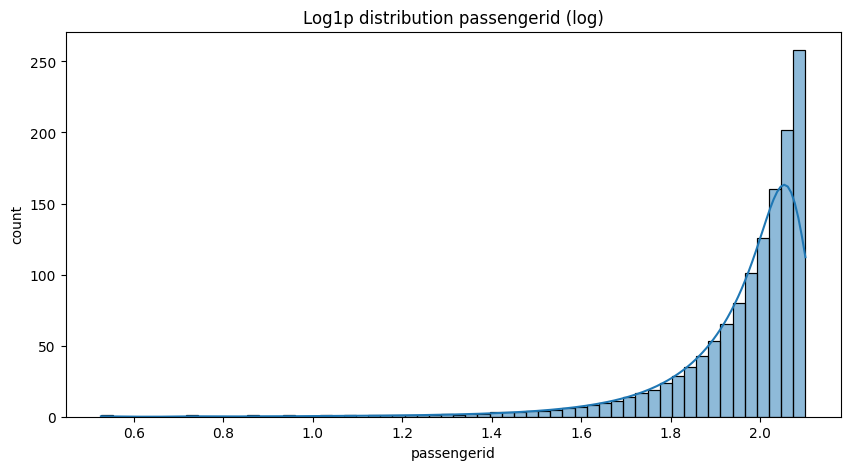

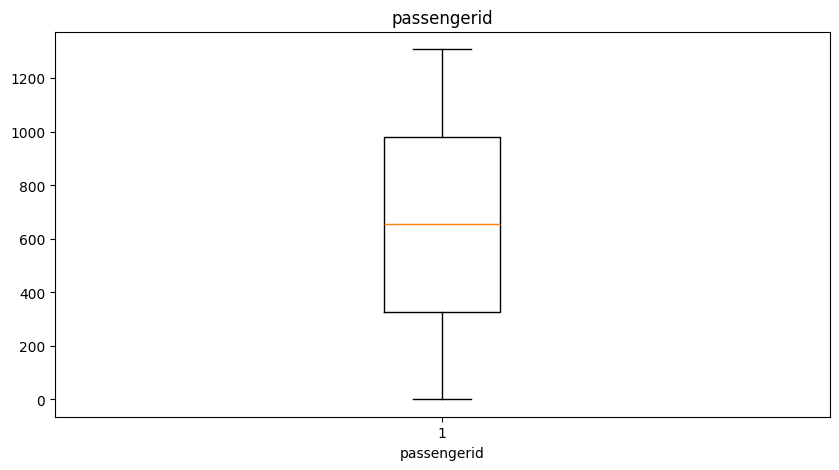


age summary: count    1309.000000
mean       29.503186
std        12.905241
min         0.170000
25%        22.000000
50%        28.000000
75%        35.000000
max        80.000000
Name: age, dtype: float64
age skew: 0.5409870816962253
age negative: 0, zero: 0, positive: 1309
age log1p skewness: -2.2888359631376556


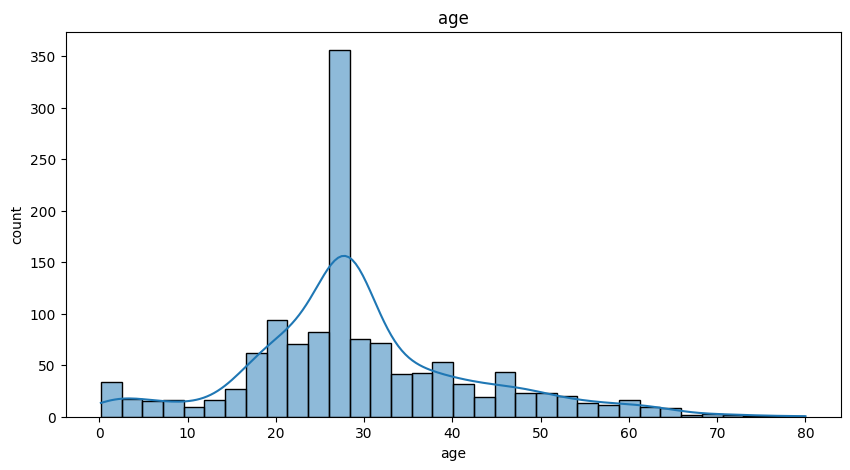

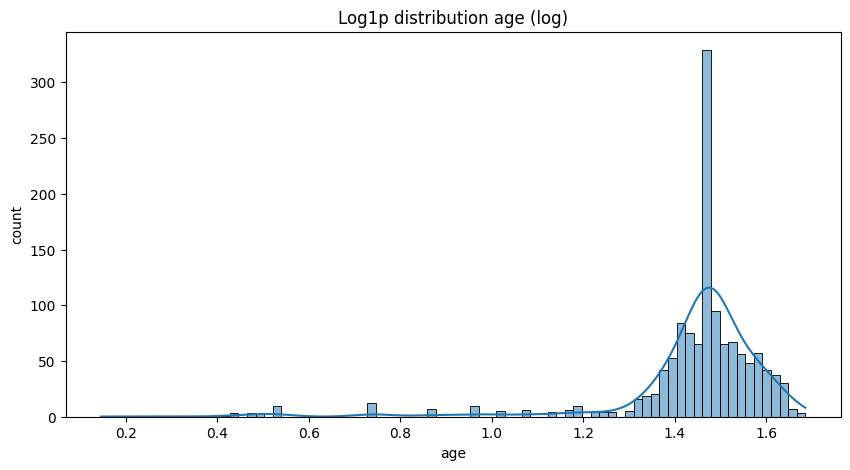

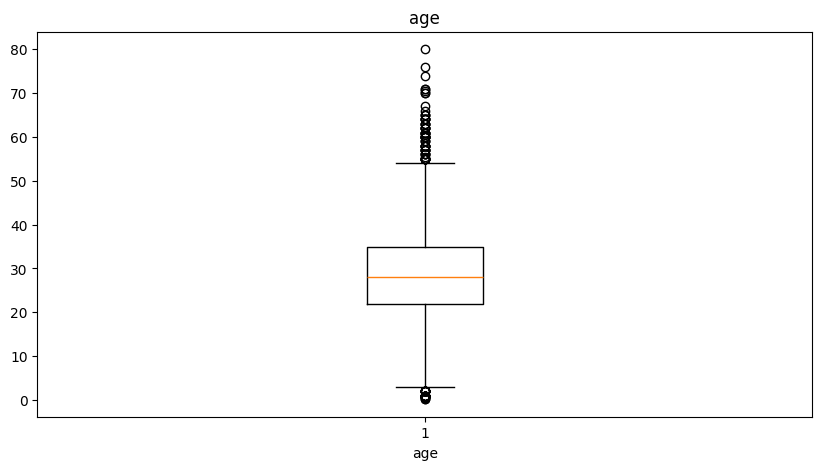


fare summary: count    1309.000000
mean       33.281086
std        51.741500
min         0.000000
25%         7.895800
50%        14.454200
75%        31.275000
max       512.329200
Name: fare, dtype: float64
fare skew: 4.3695095504693855
fare negative: 0, zero: 17, positive: 1292
fare log1p skewness: 0.5426171245242267


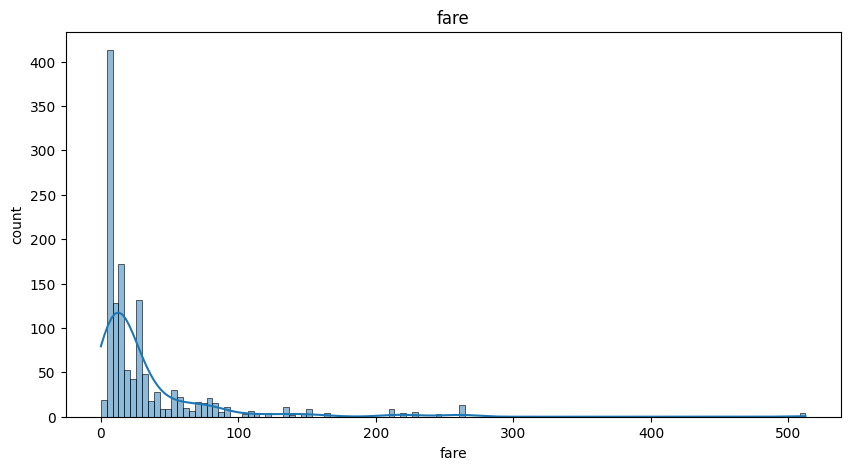

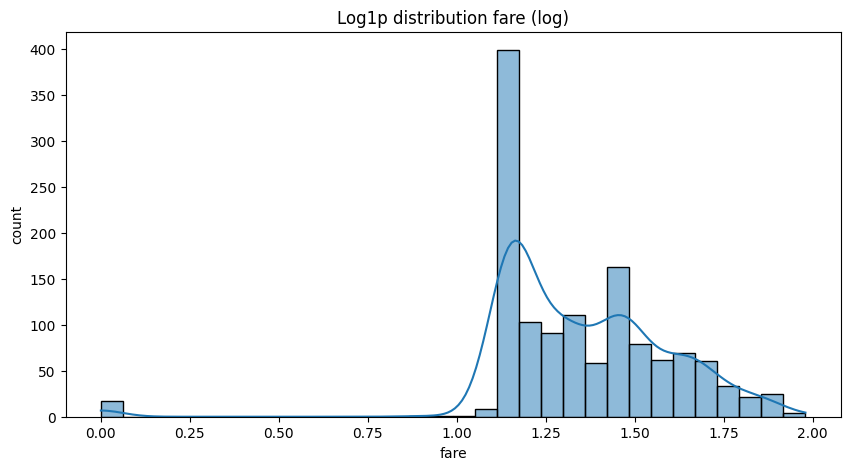

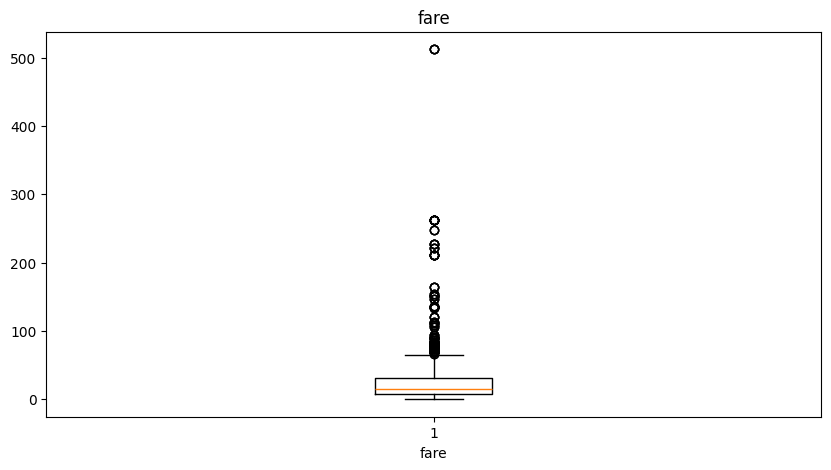


sex summary: count    1309.000000
mean        0.355997
std         0.478997
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: sex, dtype: float64
sex skew: 0.6021888531752516
sex negative: 0, zero: 843, positive: 466
sex log1p skewness: 0.6021888531752523


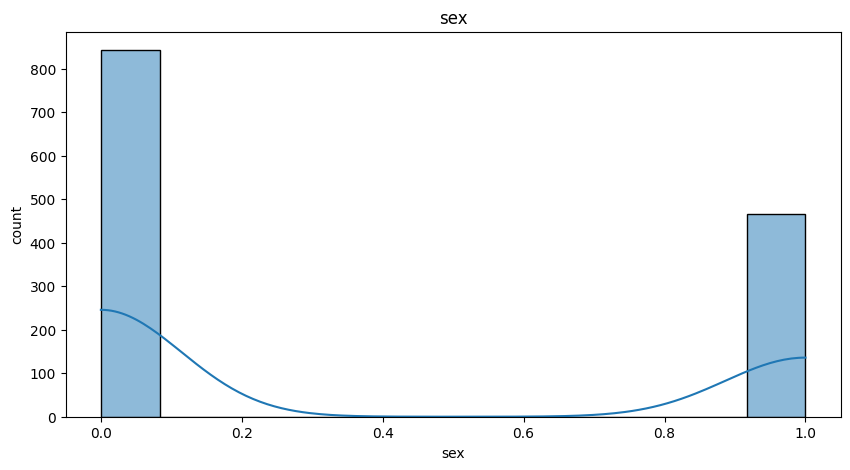

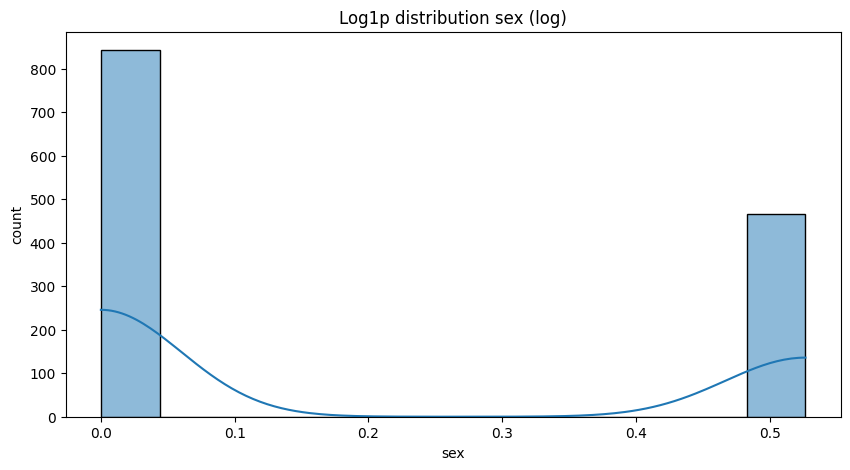

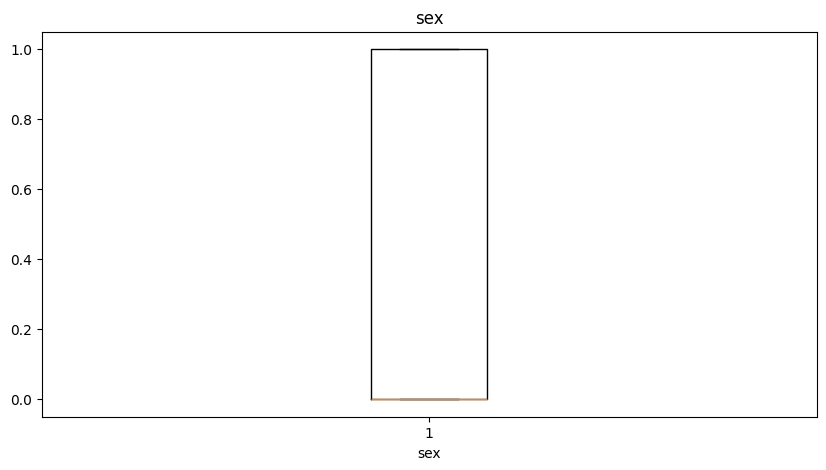


sibsp summary: count    1309.000000
mean        0.498854
std         1.041658
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         8.000000
Name: sibsp, dtype: float64
sibsp skew: 3.844220342922907
sibsp negative: 0, zero: 891, positive: 418
sibsp log1p skewness: 1.6368209762926682


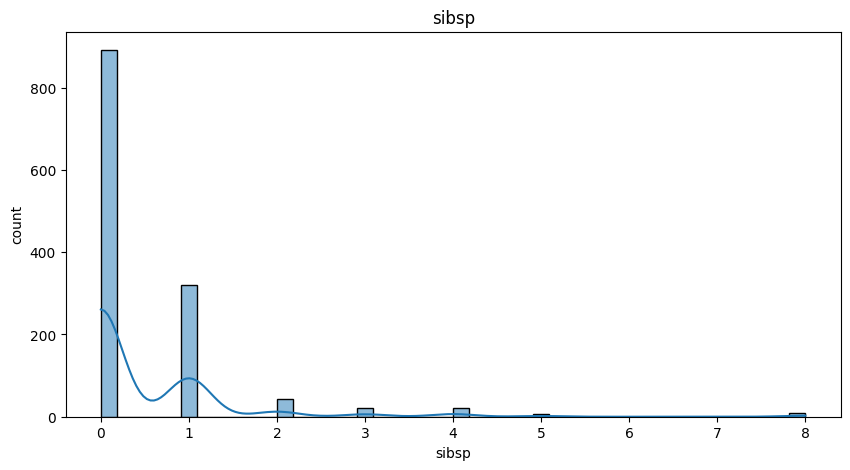

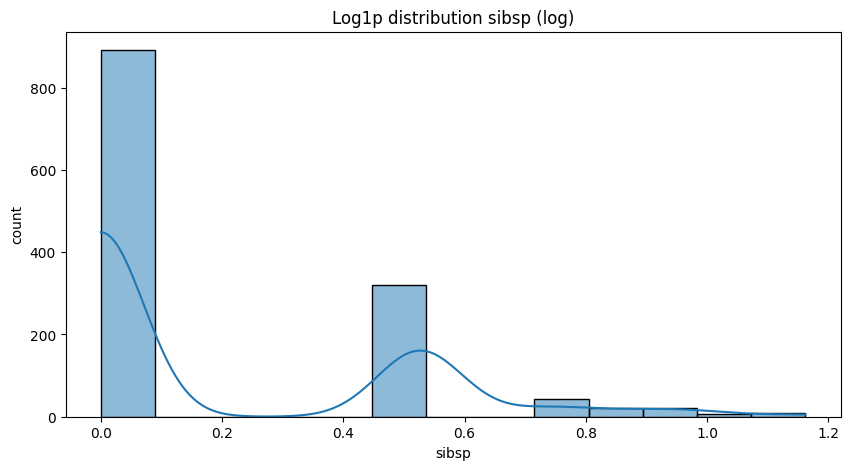

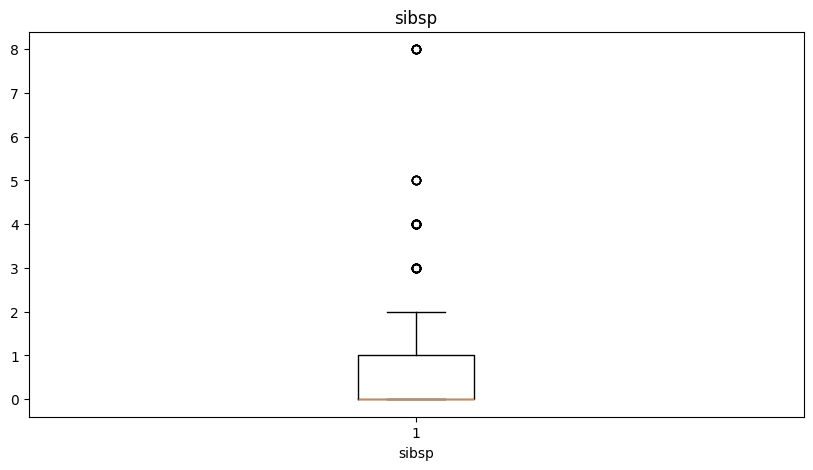


parch summary: count    1309.000000
mean        0.385027
std         0.865560
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         9.000000
Name: parch, dtype: float64
parch skew: 3.6690782036511136
parch negative: 0, zero: 1002, positive: 307
parch log1p skewness: 1.7897621054936539


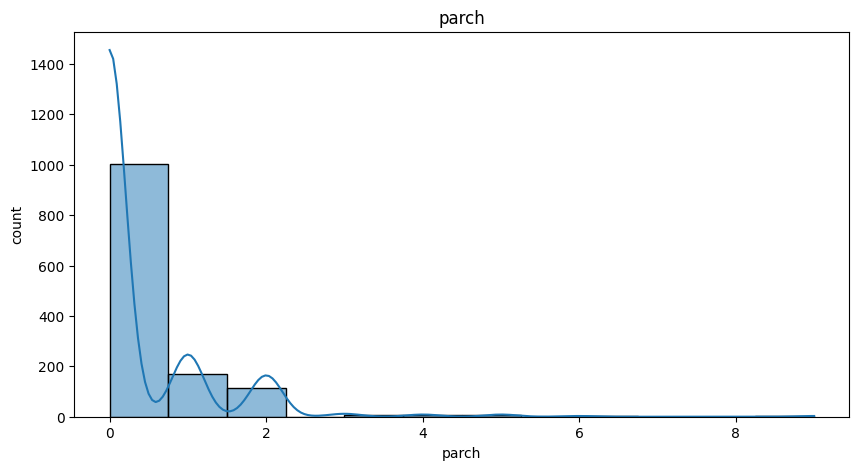

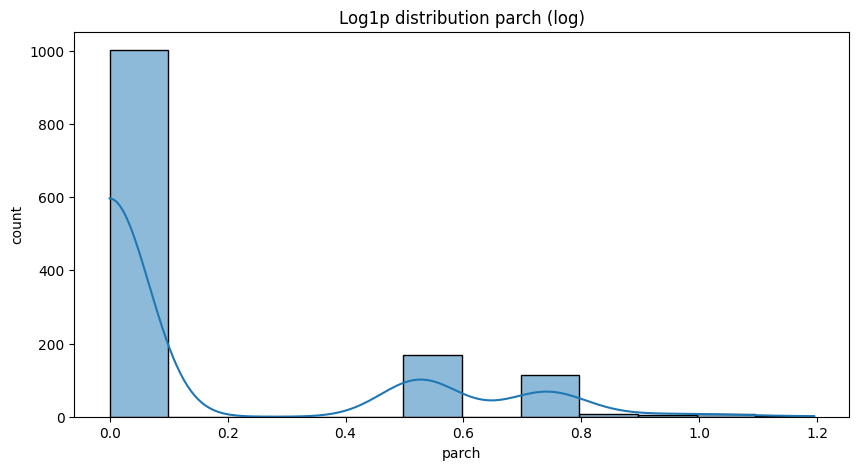

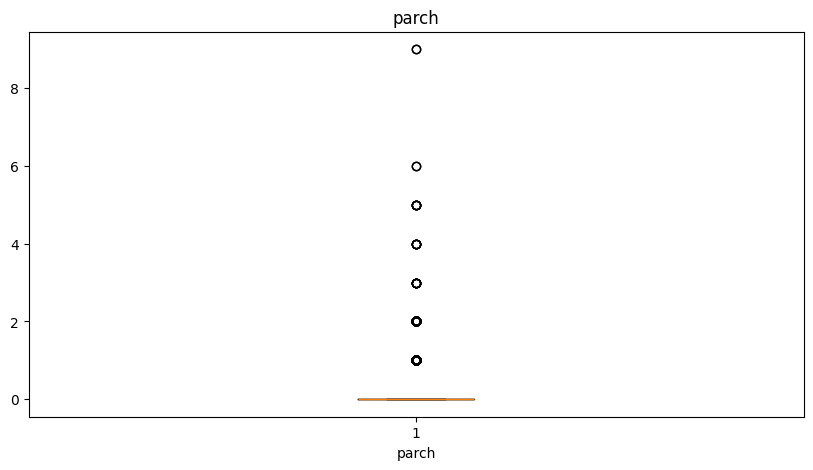

In [23]:
for col in num_cols:
  print(f'\n{col} summary: {df[col].describe()}')
  print(f'{col} skew: {df[col].skew()}')

  neg, zero, pos = (df[col] < 0).sum(), (df[col] == 0).sum(), (df[col] > 0).sum()
  print(f'{col} negative: {neg}, zero: {zero}, positive: {pos}')

  if neg == 0:
    print(f"{col} log1p skewness: {np.log1p(df[col]).skew()}")

  plot_hist(df[col], col)
  if neg == 0:
    plot_hist(np.log1p(df[col]), f"Log1p distribution {col}", log=True)
  plot_box(df[col], col)

In [24]:
def show_value_counts(df, col):
  vc = df[col].value_counts(dropna=False)
  print(f"\nValue counts for {col}:\n{vc}")

for col in num_cols:
  show_value_counts(df, col)


Value counts for passengerid:
passengerid
1309    1
1       1
2       1
3       1
4       1
       ..
18      1
17      1
16      1
15      1
14      1
Name: count, Length: 1309, dtype: int64

Value counts for age:
age
28.00    295
24.00     47
22.00     43
21.00     41
30.00     40
        ... 
60.50      1
11.50      1
0.33       1
0.17       1
38.50      1
Name: count, Length: 98, dtype: int64

Value counts for fare:
fare
8.0500     60
13.0000    59
7.7500     55
26.0000    50
7.8958     49
           ..
12.7375     1
45.5000     1
7.5750      1
7.5792      1
7.7208      1
Name: count, Length: 281, dtype: int64

Value counts for sex:
sex
0    843
1    466
Name: count, dtype: int64

Value counts for sibsp:
sibsp
0    891
1    319
2     42
4     22
3     20
8      9
5      6
Name: count, dtype: int64

Value counts for parch:
parch
0    1002
1     170
2     113
3       8
5       6
4       6
6       2
9       2
Name: count, dtype: int64


# Bivariate analysis

In [25]:
def scatter_target_vs(df, col, y_col=TARGET, sample=4000):
  plot_df = df[[col, y_col]].dropna()

  plot_df = plot_df.sample(sample) if len(plot_df) > sample else plot_df

  plt.figure()
  sns.scatterplot(x=col, y=y_col, data=plot_df)
  plt.title(f"{y_col} vs {col}")
  plt.xlabel(col)
  plt.ylabel(y_col)
  plt.show()

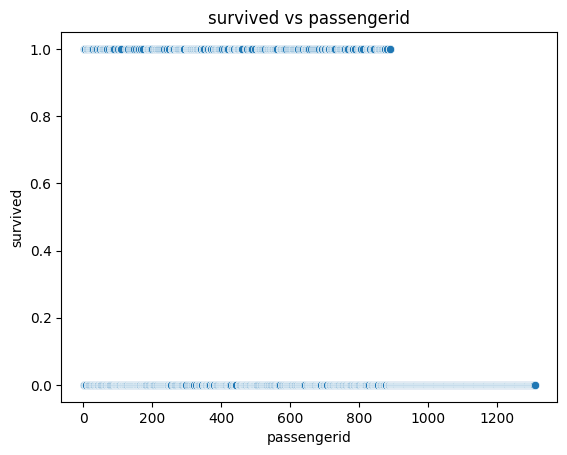

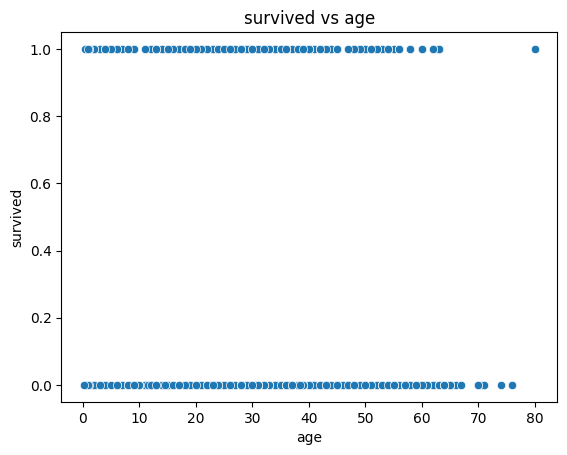

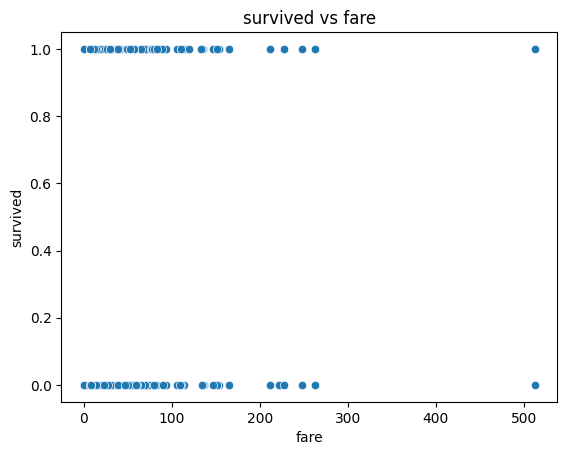

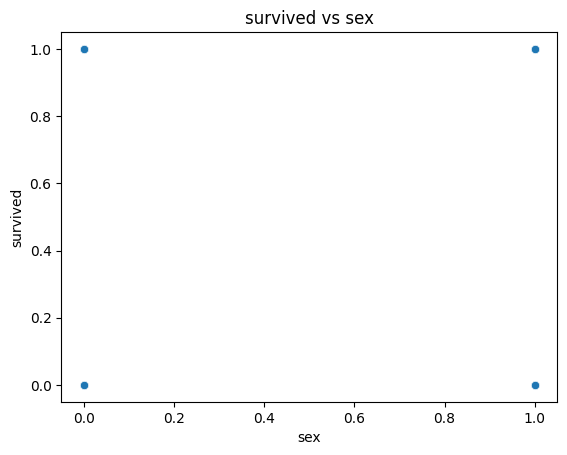

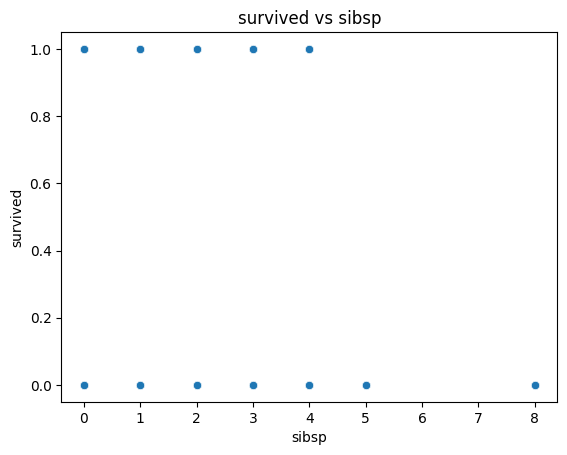

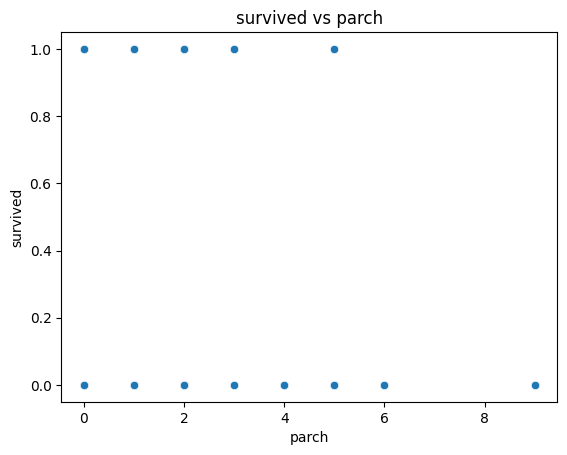

In [26]:
for col in num_cols:
  scatter_target_vs(df, col)

# Some analysis

In [27]:
df.groupby('pclass')[TARGET].mean()

,survived
pclass,
1,0.421053
2,0.314079
3,0.167842


In [28]:
df.groupby('sex')[TARGET].mean()


,survived
sex,
0,0.1293
1,0.5000


In [29]:
df.groupby('pclass')[TARGET].mean()


,survived
pclass,
1,0.421053
2,0.314079
3,0.167842


In [30]:
df.groupby(['sex', 'pclass'])[TARGET].mean()

sex  pclass
0    1         0.251397
     2         0.099415
     3         0.095335
1    1         0.631944
     2         0.660377
     3         0.333333
Name: survived, dtype: float64

In [31]:
df.groupby(TARGET)['age'].median()

,age
survived,
0,28.0
1,28.0


In [32]:
df.groupby(TARGET)['fare'].median()

,fare
survived,
0,13.0
1,26.0


In [33]:
df["familysize"] = df['sibsp'] + df["parch"] + 1
df.groupby(TARGET)["familysize"].mean()

,familysize
survived,
0,1.864529
1,1.938596


In [34]:
def corr_map(corr, y_col=TARGET):
  plt.figure(figsize=(10, 10))
  sns.heatmap(corr, annot=True, cmap="coolwarm")
  plt.title("Correlation heatmap")
  plt.show()

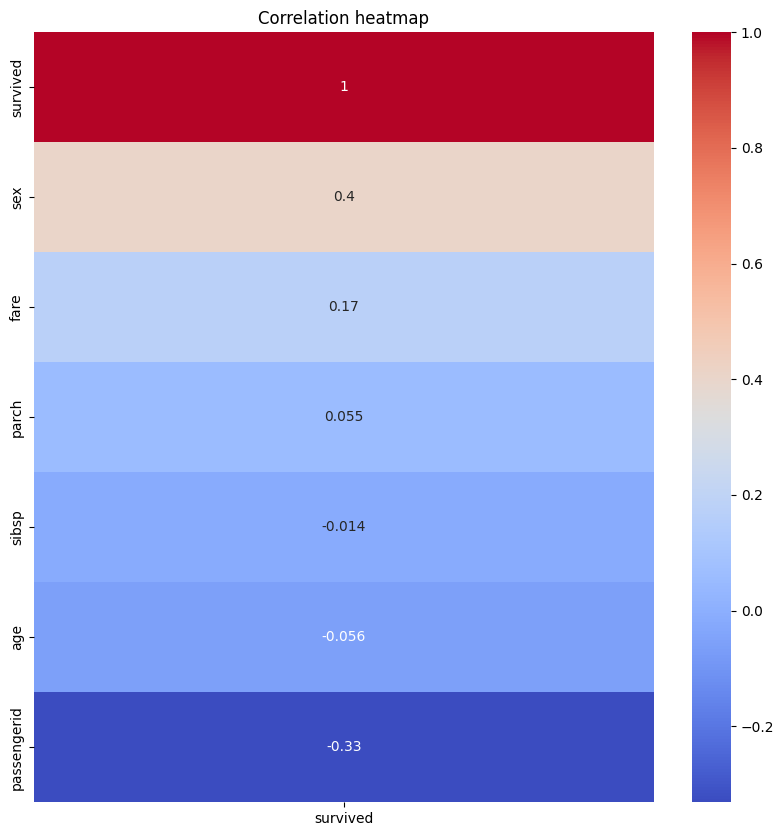

In [35]:
corr = df[[TARGET] + num_cols].corr(numeric_only=True)
corr_map(corr[[TARGET]].sort_values(TARGET, ascending=False), TARGET)

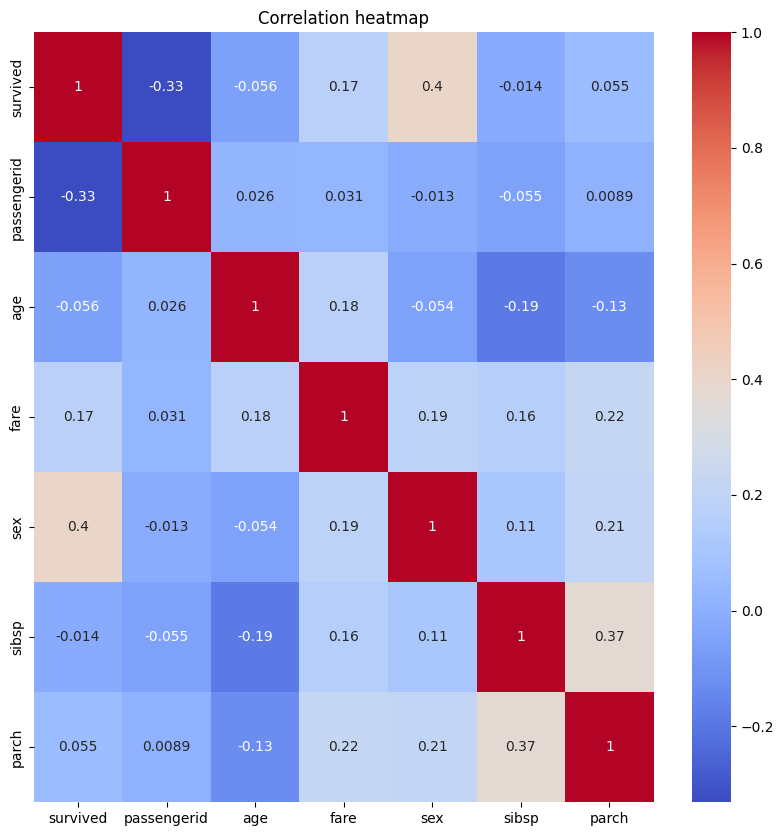

In [36]:
corr_map(corr, TARGET)

In [37]:
def boxplot_target_with_cat(df, cat_col, y_col=TARGET, topk=10, min_count=20):
  counts = df[cat_col].value_counts()
  keep = counts[counts>=min_count].index.tolist()
  sub = df[df[cat_col].isin(keep)][[cat_col, y_col]].dropna()

  if sub.empty:
    print(f"Not enough data for {cat_col}")
    return

  # order = sub.groupby(cat_col)[y_col].median().sort_values(ascending=False).index.tolist()
  # data = [sub[sub[cat_col] == k][y_col] for k in order]

  prop_df = (
        sub.groupby(cat_col)[y_col]
           .value_counts(normalize=True)
           .rename("proportion")
           .reset_index()
    )
  print(prop_df)
  plt.figure(figsize=(10, 5))
  plt.title(f"{y_col} by {cat_col} (top {topk}), min count: {min_count}")
  # plt.xticks(ticks=range(len(order)), labels=order, rotation=45)
  plt.xticks(rotation=45)
  # plt.boxplot(data, labels=order)
  sns.barplot(data=prop_df, x=cat_col, y="proportion", hue=y_col)
  # sns.boxplot(data=sub, x=cat_col, y=y_col, order=order)
  plt.show()

pclass
3    709
1    323
2    277
Name: count, dtype: int64
   pclass  survived  proportion
0       1         0    0.578947
1       1         1    0.421053
2       2         0    0.685921
3       2         1    0.314079
4       3         0    0.832158
5       3         1    0.167842


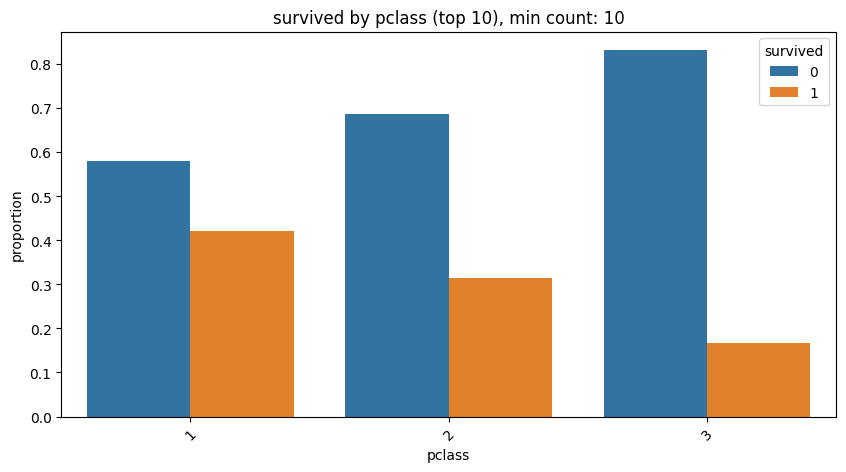

embarked
2.0    914
0.0    270
1.0    123
Name: count, dtype: int64
   embarked  survived  proportion
0       0.0         0    0.655556
1       0.0         1    0.344444
2       1.0         0    0.756098
3       1.0         1    0.243902
4       2.0         0    0.762582
5       2.0         1    0.237418


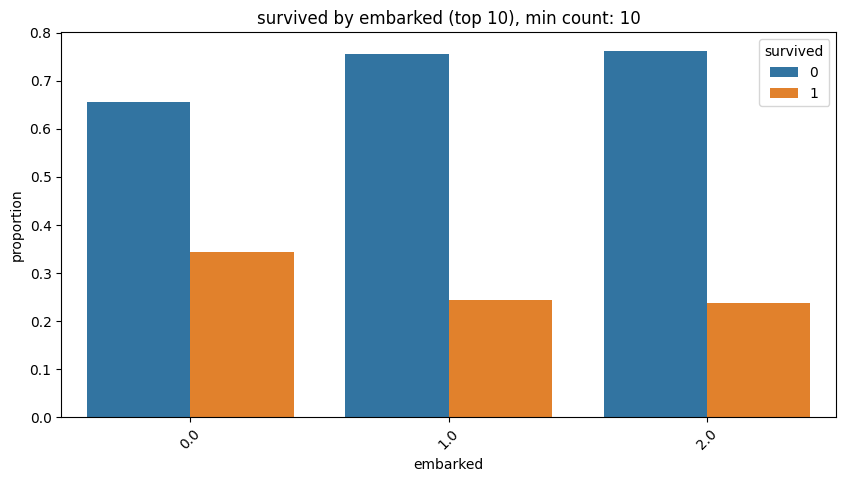

In [38]:
for col in cat_cols:
  print(df[col].value_counts())
  boxplot_target_with_cat(df, col, TARGET, 10, 10)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   passengerid  1309 non-null   int64  
 1   age          1309 non-null   float64
 2   fare         1309 non-null   float64
 3   sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   parch        1309 non-null   int64  
 6   pclass       1309 non-null   int64  
 7   embarked     1307 non-null   float64
 8   survived     1309 non-null   int64  
 9   familysize   1309 non-null   int64  
dtypes: float64(3), int64(7)
memory usage: 102.4 KB


In [40]:
col_to_drop = ['passengerid']
df2 = df.copy()

num_cols = df2.columns.tolist()
num_cols.remove(TARGET)
num_cols.remove('passengerid')
num_cols.remove('pclass')
num_cols.remove('embarked')

cat_cols = ['pclass', 'embarked']

In [41]:
df2.drop(columns=col_to_drop, inplace=True)

In [42]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   age         1309 non-null   float64
 1   fare        1309 non-null   float64
 2   sex         1309 non-null   int64  
 3   sibsp       1309 non-null   int64  
 4   parch       1309 non-null   int64  
 5   pclass      1309 non-null   int64  
 6   embarked    1307 non-null   float64
 7   survived    1309 non-null   int64  
 8   familysize  1309 non-null   int64  
dtypes: float64(3), int64(6)
memory usage: 92.2 KB


In [43]:
from sklearn.model_selection import train_test_split

X = df2.drop(columns=TARGET)
y = df2[TARGET]

X_train, X_val, y_train, y_val = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {y_train.shape}")

print(f"X_test shape: {X_val.shape}")
print(f"Y_test shape: {y_val.shape}")


X_train shape: (1047, 8)
Y_train shape: (1047,)
X_test shape: (262, 8)
Y_test shape: (262,)


In [44]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score, GridSearchCV


In [45]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocess = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols),
    ]
    )

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.dummy import DummyClassifier

RANDOM_SEED = 42

models = {
    "DummyClassifier": DummyClassifier(strategy="most_frequent"),
    "LogisticRegression": LogisticRegression(random_state=RANDOM_SEED),
    "DecisionTreeClassifier": DecisionTreeClassifier(random_state=RANDOM_SEED),
    "RandomForestClassifier": RandomForestClassifier(random_state=RANDOM_SEED),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=RANDOM_SEED),
    "XGBClassifier": XGBClassifier(random_state=RANDOM_SEED),
}

In [47]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

def evaluate_classification(y_true, y_pred, y_proba=None, prefix=""):
    out = {}
    out[f"{prefix}ACC"] = accuracy_score(y_true, y_pred)
    out[f"{prefix}F1"] = f1_score(y_true, y_pred)  # binary default pos_label=1

    # AUC needs probabilities (or decision scores)
    if y_proba is not None:
        out[f"{prefix}AUC"] = roc_auc_score(y_true, y_proba)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    out[f"{prefix}TP"] = tp
    out[f"{prefix}FP"] = fp
    out[f"{prefix}TN"] = tn
    out[f"{prefix}FN"] = fn
    return out

In [48]:
from sklearn.pipeline import Pipeline

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])

    pipe.fit(X_train, y_train)

    y_pred_val = pipe.predict(X_val)

    # get positive-class probabilities if available
    y_proba_val = None
    if hasattr(pipe, "predict_proba"):
        y_proba_val = pipe.predict_proba(X_val)[:, 1]
    elif hasattr(pipe, "decision_function"):
        # optional: convert score to something AUC can use directly
        y_proba_val = pipe.decision_function(X_val)

    metrics = evaluate_classification(y_val, y_pred_val, y_proba_val, prefix=f"{name}_")

    results.append({
        "model": name,
        "ACC": metrics.get(f"{name}_ACC"),
        "F1": metrics.get(f"{name}_F1"),
        "AUC": metrics.get(f"{name}_AUC", None),
    })

    print(f"\n{name} metrics:")
    for k, v in metrics.items():
        if k.endswith(("TP", "FP", "TN", "FN")):
            print(f" {k}: {int(v)}")
        else:
            print(f" {k}: {v:.4f}")


DummyClassifier metrics:
 DummyClassifier_ACC: 0.7405
 DummyClassifier_F1: 0.0000
 DummyClassifier_AUC: 0.5000
 DummyClassifier_TP: 0
 DummyClassifier_FP: 0
 DummyClassifier_TN: 194
 DummyClassifier_FN: 68

LogisticRegression metrics:
 LogisticRegression_ACC: 0.7481
 LogisticRegression_F1: 0.4310
 LogisticRegression_AUC: 0.7583
 LogisticRegression_TP: 25
 LogisticRegression_FP: 23
 LogisticRegression_TN: 171
 LogisticRegression_FN: 43

DecisionTreeClassifier metrics:
 DecisionTreeClassifier_ACC: 0.7252
 DecisionTreeClassifier_F1: 0.4706
 DecisionTreeClassifier_AUC: 0.6726
 DecisionTreeClassifier_TP: 32
 DecisionTreeClassifier_FP: 36
 DecisionTreeClassifier_TN: 158
 DecisionTreeClassifier_FN: 36

RandomForestClassifier metrics:
 RandomForestClassifier_ACC: 0.7634
 RandomForestClassifier_F1: 0.5231
 RandomForestClassifier_AUC: 0.7954
 RandomForestClassifier_TP: 34
 RandomForestClassifier_FP: 28
 RandomForestClassifier_TN: 166
 RandomForestClassifier_FN: 34

GradientBoostingClassifier me